### Neural Networks

In [333]:
import pandas as pd
import seaborn as sns
import sklearn
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

rng = np.random.default_rng(42)

In [334]:
train_file_path = "../../input/house-prices-advanced-regression-techniques/train.csv"
dataset_df = pd.read_csv(train_file_path)
dataset_df = dataset_df.drop('Id', axis=1)
num_df_idx = dataset_df.select_dtypes(include=['float64', 'int64']).columns
cat_df_idx = dataset_df.select_dtypes(exclude=['float64', 'int64']).columns

In [335]:
# numerical features (exclude SalePrice from standardization)
feature_num_idx = num_df_idx.drop('SalePrice')
data_mean = dataset_df[feature_num_idx].mean()
data_std = dataset_df[feature_num_idx].std()
dataset_df[feature_num_idx] = (dataset_df[feature_num_idx] - data_mean) / data_std
dataset_df[feature_num_idx] = dataset_df[feature_num_idx].fillna(0)
# catagorical features
dataset_df = pd.get_dummies(dataset_df, dummy_na=True)
print(dataset_df.shape)

(1460, 331)


In [336]:
class MyDataset(Dataset):
    def __init__(self, dataset):
        self.X = dataset[:, :-1]
        self.y = dataset[:, -1:]

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [337]:
dataset = torch.tensor(dataset_df.astype('float64').to_numpy(), dtype=torch.float32)
dataset.shape

torch.Size([1460, 331])

In [338]:
def split_dataset(dataset, vali_ratio=0.25):
    vali_indices = rng.random(len(dataset)) < vali_ratio
    return dataset[~vali_indices], dataset[vali_indices]
data_train, data_vali = split_dataset(dataset)

In [339]:
def get_k_fold_dataset(dataset, k=5):
    """
    params:
        dataset: torch.Tensor
        k: int
    return:
        train set, vali set
    """
    n = dataset.shape[0]
    fold_size = n // k
    indices = rng.permutation(n)
    start, end = 0, fold_size
    for _ in range(k):
        vali_idx = indices[start:end]
        train_idx = np.concatenate([indices[:start], indices[end:]])
        yield dataset[train_idx], dataset[vali_idx]
        start += fold_size
        end += fold_size

In [340]:
in_features = dataset.shape[1] - 1
def make_net(in_features):
    return nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.5),
        # nn.Linear(256, 256),
        # nn.ReLU(),
        # nn.Dropout(0.5),
        nn.Linear(256, 1),
    )
loss = nn.MSELoss()

In [341]:
def train(net, dataset, dataset_vali, epochs, lr, weight_decay, batch_size):
    batch_dataset = MyDataset(dataset)
    dataloader = DataLoader(batch_dataset, batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(params=net.parameters(), lr=lr, weight_decay=weight_decay)
    
    train_loss = []
    vali_loss = []
    
    for _ in range(epochs):
        net.train()
        for X, y in dataloader:
            y = torch.log1p(y)
            optimizer.zero_grad()
            l = loss(net(X), y)
            l.backward()
            optimizer.step()
        net.eval()
        with torch.no_grad():
            X = dataset[:, :-1]
            y = torch.log1p(dataset[:, -1:])
            X_vali = dataset_vali[:, :-1]
            y_vali = torch.log1p(dataset_vali[:, -1:])
            train_loss.append(np.sqrt(loss(net(X), y).item()))
            vali_loss.append(np.sqrt(loss(net(X_vali), y_vali).item()))

    return train_loss, vali_loss

In [342]:
def k_fold_train(k, dataset, epochs, lr, weight_decay, batch_size):
    """
    params:
        k: int
        other params same as train()
    return:
        avg train loss, avg vali loss
    """
    in_features = dataset.shape[1] - 1
    train_avg, vali_avg = [], []
    for data_train, data_vali in get_k_fold_dataset(dataset, k):
        net = make_net(in_features)
        train_loss, vali_loss = train(net, data_train, data_vali, epochs, lr, weight_decay, batch_size)
        train_avg.append(train_loss)
        vali_avg.append(vali_loss)
    train_avg, vali_avg = np.array(train_avg), np.array(vali_avg)
    train_avg, vali_avg = np.mean(train_avg, axis=0), np.mean(vali_avg, axis=0)
    return train_avg, vali_avg

In [343]:
# 先用默认合理参数跑一次看 baseline
k, epochs, lr, weight_decay, batch_size = 5, 250, 1e-3, 0, 64
train_loss, vali_loss = k_fold_train(k, dataset, epochs, lr, weight_decay, batch_size)
print(f"Baseline RMSLE: train={train_loss[-1]:.4f}, vali={vali_loss[-1]:.4f}, best_vali={np.min(vali_loss):.4f}")

Baseline RMSLE: train=0.0412, vali=0.0407, best_vali=0.0236


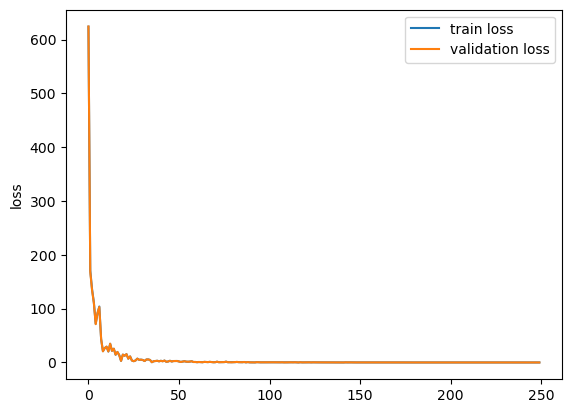

In [344]:
fig, ax = plt.subplots()
x = list(range(len(train_loss)))
ax.plot(x, train_loss, label='train loss')
ax.plot(x, vali_loss, label='validation loss')
ax.set_ylabel('loss')
ax.legend()

In [345]:
print(np.argmin(vali_loss), np.min(vali_loss))

235 0.023572834875489404


In [350]:
from itertools import product

# Step 1: 搜 lr（最重要的超参数）
k, epochs, batch_size = 5, 200, 64
lrs = [5e-3]
print("=== Step 1: 搜索 lr ===")
best_vali, best_lr = float('inf'), None
for lr in lrs:
    _, vl = k_fold_train(k, dataset, epochs, lr, 0, batch_size)
    mv = np.min(vl)
    print(f"  lr={lr} -> RMSLE={mv:.4f}")
    if mv < best_vali:
        best_vali, best_lr = mv, lr
print(f"  Best lr={best_lr}\n")

# Step 2: 固定最佳 lr，搜 weight_decay
weight_decays = [10, 50, 100]
print("=== Step 2: 搜索 weight_decay ===")
best_wd = 0
for wd in weight_decays:
    _, vl = k_fold_train(k, dataset, epochs, best_lr, wd, batch_size)
    mv = np.min(vl)
    print(f"  wd={wd} -> RMSLE={mv:.4f}")
    if mv < best_vali:
        best_vali, best_wd = mv, wd
print(f"  Best wd={best_wd}\n")

print(f"=== 最优参数: lr={best_lr}, weight_decay={best_wd}, RMSLE={best_vali:.4f} ===")

=== Step 1: 搜索 lr ===
  lr=0.005 -> RMSLE=0.0069
  Best lr=0.005

=== Step 2: 搜索 weight_decay ===
  wd=10 -> RMSLE=0.0086
  wd=50 -> RMSLE=0.0061
  wd=100 -> RMSLE=0.0102
  Best wd=50

=== 最优参数: lr=0.005, weight_decay=50, RMSLE=0.0061 ===
